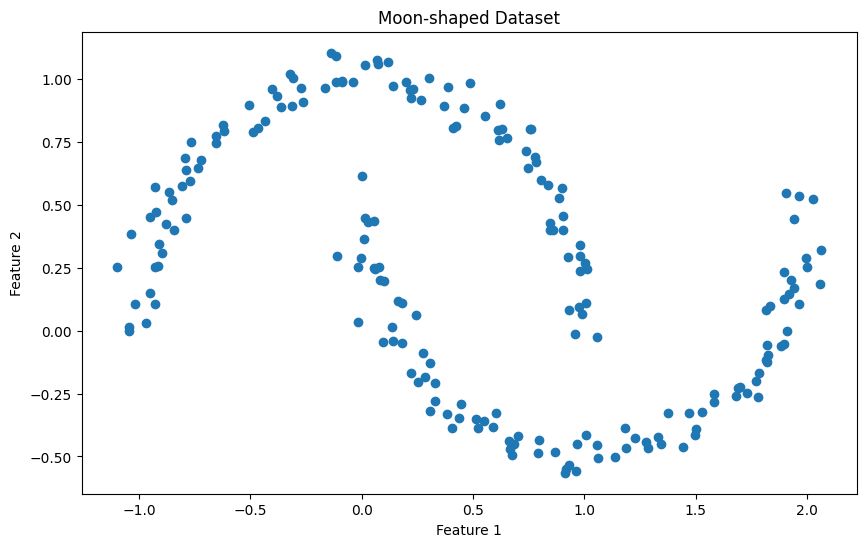

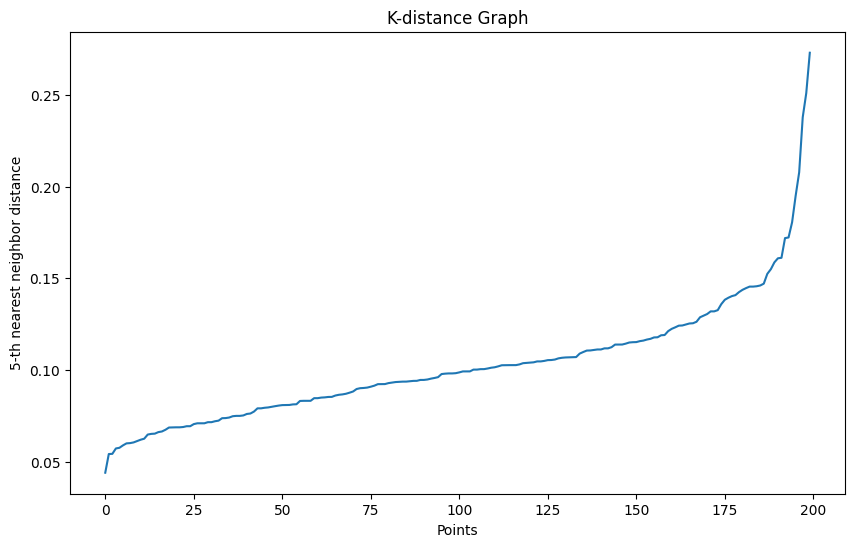

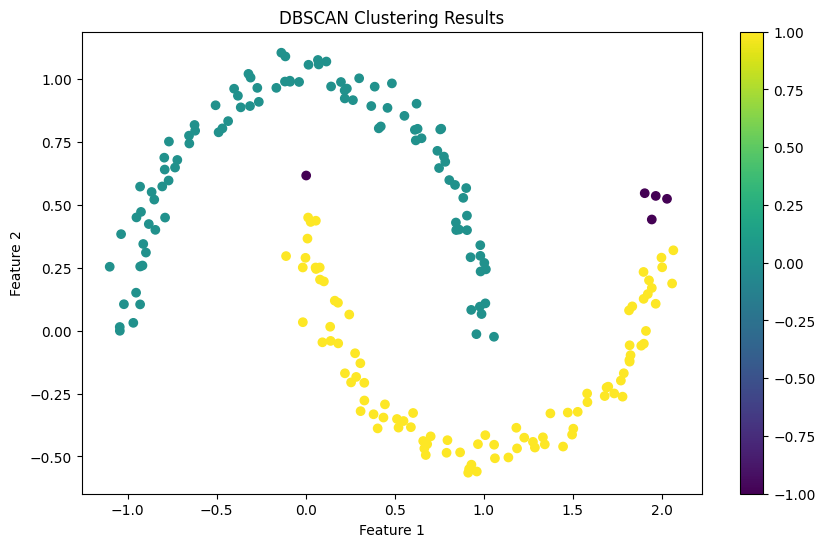

Number of clusters: 2
Number of noise points: 5


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors

X, _ = make_moons(n_samples=200, noise=0.05, random_state=42)

# Visualize the dataset
plt.figure(figsize=(10, 6))
plt.scatter(X[:, 0], X[:, 1])
plt.title('Moon-shaped Dataset')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

# Function to plot k-distance graph
def plot_k_distance_graph(X, k):
    neigh = NearestNeighbors(n_neighbors=k)
    neigh.fit(X)
    distances, _ = neigh.kneighbors(X)
    distances = np.sort(distances[:, k-1])
    plt.figure(figsize=(10, 6))
    plt.plot(distances)
    plt.xlabel('Points')
    plt.ylabel(f'{k}-th nearest neighbor distance')
    plt.title('K-distance Graph')
    plt.show()
# Plot k-distance graph
plot_k_distance_graph(X, k=5)

# Perform DBSCAN clustering
epsilon = 0.15  # Chosen based on k-distance graph
min_samples = 5  # 2 * num_features (2D data)
dbscan = DBSCAN(eps=epsilon, min_samples=min_samples)
clusters = dbscan.fit_predict(X)

# Visualize the results
plt.figure(figsize=(10, 6))
scatter = plt.scatter(X[:, 0], X[:, 1], c=clusters, cmap='viridis')
plt.colorbar(scatter)
plt.title('DBSCAN Clustering Results')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

# Print number of clusters and noise points
n_clusters = len(set(clusters)) - (1 if -1 in clusters else 0)
n_noise = list(clusters).count(-1)
print(f'Number of clusters: {n_clusters}')
print(f'Number of noise points: {n_noise}')

Customer Data:
    Spend_Per_Visit  Visit_Frequency
0              5000               50
1              5200               48
2              4800               52
3              1500               10
4              1600               12
5              1400                9
6              3000               25
7              3100               27
8              2900               24
9              8000                5
10              200                2

Clustered Data:
    Spend_Per_Visit  Visit_Frequency  Cluster
0              5000               50        0
1              5200               48        0
2              4800               52        0
3              1500               10        1
4              1600               12        1
5              1400                9        1
6              3000               25        2
7              3100               27        2
8              2900               24        2
9              8000                5       -1
10              20

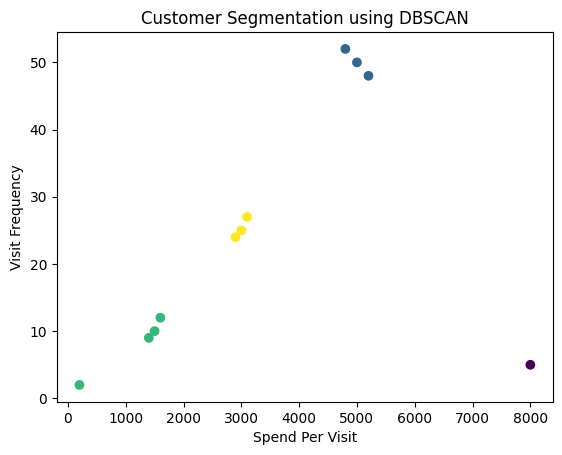

In [ ]:
# Scenario: Customer Segmentation for a Retail Store
# Context:
# A retail store wants to understand its customers better.
# They have data on how much each customer spends per visit and how frequently they visit the store.
# The goal is to group customers into clusters (e.g., “loyal high spenders,” “occasional visitors,” etc.) using DBSCAN,
# which is great for finding clusters of varying shapes and identifying outliers.


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

# Customer data: [Spend_Per_Visit, Visit_Frequency]
data = np.array([
    [5000, 50], [5200, 48], [4800, 52],   # Loyal high spenders
    [1500, 10], [1600, 12], [1400, 9],    # Occasional visitors
    [3000, 25], [3100, 27], [2900, 24],   # Moderate spenders
    [8000, 5],                            # Outlier: rare but huge spender
    [200, 2],                             # Outlier: very low engagement
])

# Create DataFrame with column names
df = pd.DataFrame(data, columns=["Spend_Per_Visit", "Visit_Frequency"])

print("Customer Data:")
print(df)

# Feature Scaling
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)

# Apply DBSCAN
dbscan = DBSCAN(eps=0.8, min_samples=2)
clusters = dbscan.fit_predict(scaled_data)

# Add cluster labels
df["Cluster"] = clusters

print("\nClustered Data:")
print(df)

# Plot clusters
plt.scatter(df["Spend_Per_Visit"], df["Visit_Frequency"], c=df["Cluster"])

plt.xlabel("Spend Per Visit")
plt.ylabel("Visit Frequency")
plt.title("Customer Segmentation using DBSCAN")

plt.show()

In [ ]:
#Fine tuning a pretrained model
# Scenario: Fine-tune ResNet-50 pretrained on ImageNet
#  to classify 5 types of plant disease from 3,000 leaf images.

# Import PyTorch main library
# PyTorch is used for building and training deep learning models
import torch

# Import torchvision which contains datasets, pretrained models and image
#  utilities
import torchvision

# Import neural network module from PyTorch
# nn contains layers like Linear, Conv2D, ReLU etc.
import torch.nn as nn

# Import pretrained models and image transformations
from torchvision import models, transforms

# Import DataLoader to load dataset in batches
from torch.utils.data import DataLoader

# Import ImageFolder dataset loader
# This loads images arranged in folder structure
# Example:
# dataset/
#     disease1/
#     disease2/
#     disease3/
from torchvision.datasets import ImageFolder


# ---------------------------------------------------------
# STEP 1 : Load a Pretrained ResNet-50 Model
# ---------------------------------------------------------


# ResNet50 is a deep CNN with 50 layers designed by Microsoft
# It is trained on ImageNet dataset (~1.2 million images, 1000 classes)


# Using pretrained weights helps the model already know
# basic visual features like edges, shapes, textures etc.

model = models.resnet50(weights='IMAGENET1K_V2')

# weights='IMAGENET1K_V2'
# loads pretrained weights trained on ImageNet
# This technique is called TRANSFER LEARNING

# Instead of training from scratch,
# we reuse knowledge learned from a huge dataset.


# ---------------------------------------------------------
# STEP 2 : Freeze ALL layers
# ---------------------------------------------------------

# Freezing means we stop updating weights during training

# Why freeze?
# Because the early layers already learned useful
# general visual features like:
# edges
# corners
# textures
# patterns

# We only want to train the final layers for our dataset.

for param in model.parameters():
    param.requires_grad = False

# requires_grad = False means:
# PyTorch will NOT compute gradients for these parameters
# during backpropagation.

# Result:
# The pretrained weights stay unchanged.


# ---------------------------------------------------------
# STEP 3 : Replace the classifier head (Fully Connected layer)
# ---------------------------------------------------------

# ResNet originally outputs 1000 classes (ImageNet classes)
# But our plant disease dataset has only 5 classes.

num_classes = 5

# The final layer of ResNet is:
# model.fc

# We replace it with a custom classifier.

model.fc = nn.Sequential(

    # Dropout randomly disables neurons during training
    # Helps reduce overfitting
    nn.Dropout(0.4),

    # First fully connected layer
    # model.fc.in_features gives the number of input features
    # from the previous ResNet layer (usually 2048)

    nn.Linear(model.fc.in_features, 256),

    # ReLU activation introduces non-linearity
    # Helps model learn complex patterns
    nn.ReLU(),

    # Final layer outputs probabilities for each class
    nn.Linear(256, num_classes)
)

# Architecture of new classifier:
#
# Feature Vector (2048)
#        ↓
#     Dropout
#        ↓
#   Linear (2048 → 256)
#        ↓
#       ReLU
#        ↓
#   Linear (256 → 5 classes)


# ---------------------------------------------------------
# STEP 4 : Unfreeze last residual block (Fine-Tuning)
# ---------------------------------------------------------

# ResNet architecture is divided into blocks:
#
# conv1
# layer1
# layer2
# layer3
# layer4
# fc

# layer4 is the deepest feature extraction block.

# We unfreeze it so the network can slightly adjust
# high-level features for plant diseases.

for param in model.layer4.parameters():
    param.requires_grad = True

# This technique is called:
# FINE-TUNING

# Strategy used here:
#
# Early layers  → Frozen (generic features)
# Deep layers   → Trainable (task-specific features)
# Classifier    → Fully trainable


# ---------------------------------------------------------
# STEP 5 : Differential Learning Rates
# ---------------------------------------------------------

# Different parts of the network learn at different speeds.

# Pretrained layers need SMALL learning rate
# because we only want small adjustments.

# New classifier layers need HIGHER learning rate
# because they are randomly initialized.

optimizer = torch.optim.Adam([

    # Lower learning rate for pretrained layer4
    {'params': model.layer4.parameters(), 'lr': 1e-4},

    # Higher learning rate for new classifier head
    {'params': model.fc.parameters(), 'lr': 1e-3},
])

# Adam optimizer:
# Adaptive learning rate optimization algorithm
# Combines benefits of Momentum and RMSProp

# Learning rates:
#
# layer4 → 0.0001 (small updates)
# fc     → 0.001  (faster learning)


# ---------------------------------------------------------
# STEP 6 : Loss Function
# ---------------------------------------------------------

# CrossEntropyLoss is used for multi-class classification.

criterion = nn.CrossEntropyLoss()

# It combines:
#
# LogSoftmax + Negative Log Likelihood

# Expected input:
#
# Model output → raw logits
# Target → class index (0,1,2,3,4)

# Example:
#
# Output = [2.1, -1.2, 0.5, 3.4, -0.7]
# Target = 3


# ---------------------------------------------------------
# FINAL TRAINING FLOW
# ---------------------------------------------------------

# During training the process is:

# 1️⃣ Input image
#        ↓
# 2️⃣ ResNet pretrained layers (mostly frozen)
#        ↓
# 3️⃣ Layer4 (fine-tuned)
#        ↓
# 4️⃣ Custom classifier (fc)
#        ↓
# 5️⃣ Output logits for 5 plant diseases
#        ↓
# 6️⃣ CrossEntropyLoss calculates error
#        ↓
# 7️⃣ Backpropagation
#        ↓
# 8️⃣ Only layer4 + fc weights update

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 149MB/s]


In [ ]:
# Scenario: Your fine-tuned model hits 78% validation accuracy but
#  training accuracy is 96%. Classic overfitting. Here are your levers.
# ---------------------------------------------------------
# Import required libraries
# ---------------------------------------------------------

from torchvision import transforms      # Provides image preprocessing and augmentation utilities
import torch.optim as optim             # Contains optimization algorithms used during training
import torch                            # Core PyTorch library
import torch.nn as nn                   # Neural network layers and loss functions
import numpy as np                      # Used here to sample from Beta distribution for MixUp


# ---------------------------------------------------------
# DATA AUGMENTATION PIPELINE
# ---------------------------------------------------------

# Compose() chains multiple image transformations together
# Each transformation is applied sequentially to the input image
train_tf = transforms.Compose([

    # Randomly crop a region of the image and resize it to 224x224
    # scale=(0.7,1.0) means crop size will be between 70%–100% of the original image
    transforms.RandomResizedCrop(224, scale=(0.7, 1.0)),

    # Randomly flip the image horizontally with 50% probability
    # Helps model learn orientation-invariant features
    transforms.RandomHorizontalFlip(p=0.5),

    # Randomly flip image vertically with 20% probability
    # Adds more variation in orientation
    transforms.RandomVerticalFlip(p=0.2),

    # Randomly change image brightness, contrast and saturation
    # Helps model generalize across lighting conditions
    transforms.ColorJitter(
        brightness=0.3,
        contrast=0.3,
        saturation=0.2
    ),

    # Randomly rotate the image between -15° and +15°
    # Improves robustness to rotated objects
    transforms.RandomRotation(degrees=15),

    # Convert some images to grayscale with probability 0.1
    # Forces model to rely on shapes and textures rather than color only
    transforms.RandomGrayscale(p=0.1),

    # Convert image from PIL format to PyTorch tensor
    # Also scales pixel values from 0–255 to 0–1
    transforms.ToTensor(),

    # Normalize tensor using ImageNet mean and standard deviation
    # This is required when using pretrained ImageNet models
    transforms.Normalize(
        [0.485,0.456,0.406],   # mean for RGB channels
        [0.229,0.224,0.225]    # standard deviation for RGB channels
    ),

    # Randomly erase a rectangular region of the image
    # This technique is also called "Cutout regularization"
    # Prevents the model from focusing only on one region
    transforms.RandomErasing(p=0.2),

])


# ---------------------------------------------------------
# MIXUP DATA AUGMENTATION
# ---------------------------------------------------------

# MixUp creates new training samples by blending two images together
# This improves generalization and reduces overfitting

def mixup_data(x, y, alpha=0.4):

    # Sample mixing coefficient (lambda) from Beta distribution
    # Beta distribution ensures lambda is between 0 and 1
    lam = np.random.beta(alpha, alpha)

    # Randomly shuffle indices of the batch
    # This determines which image will be mixed with which
    idx = torch.randperm(x.size(0))

    # Create mixed images
    # New image = lam * imageA + (1-lam) * imageB
    mixed_x = lam * x + (1 - lam) * x[idx]

    # Return mixed images and both labels
    # Loss will be computed using both labels weighted by lambda
    return mixed_x, y, y[idx], lam


# ---------------------------------------------------------
# LEARNING RATE SCHEDULER
# ---------------------------------------------------------

# CosineAnnealingLR gradually reduces the learning rate
# following a cosine curve during training

scheduler = optim.lr_scheduler.CosineAnnealingLR(

    optimizer,      # optimizer whose learning rate will be scheduled

    T_max = 50,     # number of epochs before the learning rate reaches minimum

    eta_min = 1e-6  # minimum learning rate value

)

# Why use cosine annealing?
# • Smooth learning rate decay
# • Prevents sudden learning rate drops
# • Often improves convergence in deep learning models


# ---------------------------------------------------------
# LOSS FUNCTION WITH LABEL SMOOTHING
# ---------------------------------------------------------

# CrossEntropyLoss is commonly used for multi-class classification

criterion = nn.CrossEntropyLoss(

    label_smoothing = 0.1   # distributes a small probability mass to other classes

)

# Normally labels look like:
# [0,0,0,1,0]

# With label smoothing (0.1):
# [0.025,0.025,0.025,0.9,0.025]

# Benefits:
# • prevents overconfident predictions
# • improves generalization
# • reduces overfitting


# ---------------------------------------------------------
# GRADIENT CLIPPING
# ---------------------------------------------------------

# Gradient clipping prevents exploding gradients during backpropagation

torch.nn.utils.clip_grad_norm_(

    model.parameters(),   # parameters whose gradients will be clipped

    max_norm = 1.0        # maximum allowed gradient norm

)

# If gradient norm becomes larger than 1.0
# it will be scaled down automatically

# This stabilizes training especially in deep neural networks

tensor(0.)

In [ ]:
# 🎯 Scenario: Medical Image Classification
# You’re training a convolutional neural network (CNN) to detect pneumonia from chest X-rays.
# - Training accuracy: 95%
# - Validation accuracy: 74%
# At first glance, the model seems powerful — it almost perfectly classifies the training set. But the sharp drop in validation accuracy signals overfitting: the network has memorized the training images (specific pixel patterns, noise, or even hospital-specific artifacts) instead of learning generalizable features of pneumonia.

# ⚙️ Levers to Address Overfitting
# - Data Augmentation: Rotate, flip, and adjust brightness of X-rays to simulate variability.
# - Regularization: Apply dropout in dense layers or L2 weight decay.
# - Transfer Learning: Use a pretrained backbone (e.g., ResNet) to leverage generalized features.
# - Cross-validation: Ensure robustness across different patient subsets.
# - Early Stopping: Halt training when validation loss stops improving.


# 1. Data Preparation
# -----------------------------
# Assume spectrograms are stored as images in folders:
# dataset_root/
#   ├── train/
#   │   ├── rock/
#   │   ├── jazz/
#   │   ├── classical/
#   │   ├── hiphop/
#   │   └── electronic/
#   └── val/ (same structure)

# ---------------------------------------------------------
# Import required libraries
# ---------------------------------------------------------

from torchvision import transforms      # Image preprocessing & augmentation
from torchvision import datasets        # Load images from folder structure
from torch.utils.data import DataLoader # Creates batches for training
import torch.optim as optim             # Optimizers
import torch.nn as nn                   # Loss functions & layers
import torch                            # PyTorch core
import numpy as np                      # For random sampling (MixUp etc.)

# ---------------------------------------------------------
# DATA AUGMENTATION FOR CHEST X-RAYS
# ---------------------------------------------------------

train_tf = transforms.Compose([

    # Random crop + resize to standard input size
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),

    # Horizontal flip (safe for X-rays)
    transforms.RandomHorizontalFlip(p=0.5),

    # Small rotation to simulate patient positioning
    transforms.RandomRotation(degrees=10),

    # Slight brightness / contrast change
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2
    ),

    # Convert to tensor
    transforms.ToTensor(),

    # Normalize using ImageNet stats (needed for pretrained models)
    transforms.Normalize(
        [0.485, 0.456, 0.406],
        [0.229, 0.224, 0.225]
    ),

    # Random erasing → prevents focus on single artifact
    transforms.RandomErasing(p=0.15)

])

# ---------------------------------------------------------
# VALIDATION TRANSFORM (NO AUGMENTATION)
# ---------------------------------------------------------

val_tf = transforms.Compose([

    transforms.Resize((224,224)),

    transforms.ToTensor(),

    transforms.Normalize(
        [0.485,0.456,0.406],
        [0.229,0.224,0.225]
    )

])

# ---------------------------------------------------------
# DATASET LOADING (Folder structure given in question)
# ---------------------------------------------------------


train_ds = datasets.ImageFolder(
    "dataset_root/train",
    transform=train_tf
)

val_ds = datasets.ImageFolder(
    "dataset_root/val",
    transform=val_tf
)

train_loader = DataLoader(
    train_ds,
    batch_size=32,
    shuffle=True
)

val_loader = DataLoader(
    val_ds,
    batch_size=32,
    shuffle=False
)

# ---------------------------------------------------------
# TRANSFER LEARNING (Use pretrained ResNet)
# ---------------------------------------------------------

from torchvision.models import resnet18

model = resnet18(pretrained=True)

# Replace final layer for binary classification (pneumonia / normal)
model.fc = nn.Linear(
    model.fc.in_features,
    2
)

# ---------------------------------------------------------
# REGULARIZATION (Dropout + Weight decay)
# ---------------------------------------------------------

optimizer = optim.Adam(

    model.parameters(),

    lr = 1e-4,

    weight_decay = 1e-4   # L2 regularization

)

model.fc = nn.Sequential(

    nn.Dropout(0.5),

    nn.Linear(model.fc.in_features, 2)

)

# ---------------------------------------------------------
# LOSS FUNCTION WITH LABEL SMOOTHING
# ---------------------------------------------------------

criterion = nn.CrossEntropyLoss(

    label_smoothing = 0.1

)

# ---------------------------------------------------------
# LEARNING RATE SCHEDULER
# ---------------------------------------------------------

scheduler = optim.lr_scheduler.CosineAnnealingLR(

    optimizer,

    T_max = 30,

    eta_min = 1e-6

)

# ---------------------------------------------------------
# EARLY STOPPING LOGIC
# ---------------------------------------------------------

best_val_loss = 999
patience = 5
counter = 0

if val_loss < best_val_loss:
    best_val_loss = val_loss
    counter = 0
else:
    counter += 1

if counter >= patience:
    print("Stop training → overfitting started")
    break


# ---------------------------------------------------------
# OPTIONAL: MIXUP (Strong regularization)
# ---------------------------------------------------------

def mixup_data(x, y, alpha=0.4):

    lam = np.random.beta(alpha, alpha)

    idx = torch.randperm(x.size(0))

    mixed_x = lam * x + (1 - lam) * x[idx]

    return mixed_x, y, y[idx], lam

FileNotFoundError: [Errno 2] No such file or directory: 'dataset_root/train'

In [ ]:
# Hyperparameter Tuning
# Scenario: You need to tune LR, batch size, dropout,
# and weight decay for your plant classifier. Manual search takes weeks. Optuna does it overnight.

# ============================================================
# IMPORT REQUIRED LIBRARIES
# ============================================================

!pip install optuna
import optuna
# Optuna is an automatic hyperparameter optimization framework.
# It runs multiple experiments (called trials) and searches for
# the best hyperparameter combination.

import torch
# Core PyTorch library used for tensor computation and deep learning.

import torch.nn as nn
# Contains neural network layers and loss functions.

import torch.nn.functional as F
# Functional API for neural network operations (activations, loss, etc.)

import torch.optim as optim
# Contains optimization algorithms such as Adam and SGD.

from torch.utils.data import DataLoader, TensorDataset
# DataLoader loads data in batches.
# TensorDataset wraps tensors so they can behave like a dataset.


# ============================================================
# 1. DEFINE A SIMPLE MODEL BUILDER FUNCTION
# ============================================================

def build_model(dropout=0.5):

    # This function constructs a neural network architecture.
    # The dropout parameter is supplied by Optuna so that
    # each trial can test a different dropout value.

    # The network below is a simple feedforward neural network
    # designed for MNIST-like data (28x28 grayscale images).

    model = nn.Sequential(

        nn.Linear(28*28, 128),
        # Fully connected layer
        # Input size = 28×28 pixels (flattened image)
        # Output size = 128 neurons

        nn.ReLU(),
        # ReLU activation function introduces non-linearity.
        # Formula: f(x) = max(0, x)

        nn.Dropout(dropout),
        # Randomly disables neurons during training.
        # Helps prevent overfitting.
        # Dropout value is chosen by Optuna.

        nn.Linear(128, 10)
        # Final classification layer.
        # Output size = 10 classes (digits 0–9).
    )

    return model
    # Return the constructed neural network.


# ============================================================
# 2. DEFINE TRAINING AND EVALUATION FUNCTION
# ============================================================

def train_and_evaluate(model, optimizer, batch_size):

    # This function performs:
    # 1. Training the model
    # 2. Evaluating validation accuracy

    # --------------------------------------------------------
    # Create a dummy dataset
    # --------------------------------------------------------

    X = torch.randn(500, 28*28)
    # Generate 500 random samples.
    # Each sample represents a flattened 28×28 image.

    y = torch.randint(0, 10, (500,))
    # Random labels between 0 and 9.

    dataset = TensorDataset(X, y)
    # Combines feature tensor X and label tensor y into a dataset.

    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
    # DataLoader loads data in batches.
    # batch_size is selected by Optuna.
    # shuffle=True randomizes data order each epoch.

    criterion = nn.CrossEntropyLoss()
    # Loss function used for multi-class classification.


    # --------------------------------------------------------
    # Training Phase
    # --------------------------------------------------------

    model.train()
    # Set model to training mode (enables dropout).

    for xb, yb in loader:

        optimizer.zero_grad()
        # Reset gradients from previous iteration.

        out = model(xb)
        # Forward pass through the neural network.

        loss = criterion(out, yb)
        # Compute classification loss.

        loss.backward()
        # Backpropagation: compute gradients.

        optimizer.step()
        # Update model parameters using optimizer.


    # --------------------------------------------------------
    # Validation Phase
    # --------------------------------------------------------

    model.eval()
    # Switch model to evaluation mode.
    # Disables dropout and other training-only layers.

    correct = 0

    with torch.no_grad():
        # Disable gradient computation during evaluation.

        for xb, yb in loader:

            preds = model(xb).argmax(dim=1)
            # Predict class with highest probability.

            correct += (preds == yb).sum().item()
            # Count correct predictions.

    val_acc = correct / len(dataset)
    # Compute validation accuracy.

    return val_acc
    # Return accuracy to Optuna.


# ============================================================
# 3. DEFINE OPTUNA OBJECTIVE FUNCTION
# ============================================================

def objective(trial):

    # The objective function defines one Optuna trial.
    # Each trial samples new hyperparameters and evaluates them.


    # --------------------------------------------------------
    # Sample Hyperparameters
    # --------------------------------------------------------

    lr = trial.suggest_float('lr', 1e-5, 1e-2, log=True)
    # Learning rate sampled between 0.00001 and 0.01.
    # log=True samples values on logarithmic scale.

    batch_size = trial.suggest_categorical('batch_size', [16, 32, 64])
    # Batch size selected from predefined options.

    dropout = trial.suggest_float('dropout', 0.1, 0.5)
    # Dropout rate between 0.1 and 0.5.

    weight_decay = trial.suggest_float('wd', 1e-5, 1e-2, log=True)
    # Weight decay (L2 regularization) parameter.

    optimizer_name = trial.suggest_categorical('optimizer', ['Adam','SGD'])
    # Select optimizer algorithm.


    # --------------------------------------------------------
    # Build Model
    # --------------------------------------------------------

    model = build_model(dropout=dropout)
    # Create neural network with sampled dropout.


    # --------------------------------------------------------
    # Create Optimizer
    # --------------------------------------------------------

    optimizer = getattr(optim, optimizer_name)(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay
    )

    # getattr dynamically selects optimizer:
    # If optimizer_name = "Adam"
    # → optim.Adam
    #
    # If optimizer_name = "SGD"
    # → optim.SGD


    # --------------------------------------------------------
    # Train Model and Compute Validation Accuracy
    # --------------------------------------------------------

    val_acc = train_and_evaluate(model, optimizer, batch_size)

    return val_acc
    # Optuna will try to maximize this value.


# ============================================================
# 4. CREATE AND RUN OPTUNA STUDY
# ============================================================

study = optuna.create_study(

    direction='maximize',
    # Indicates we want to maximize validation accuracy.

    pruner=optuna.pruners.MedianPruner()
    # Stops trials early if they perform worse than median
    # of previous trials. This speeds up optimization.
)


study.optimize(objective, n_trials=10)
# Runs hyperparameter optimization for 10 trials.
# Each trial tests a different hyperparameter configuration.


# ============================================================
# PRINT BEST RESULTS
# ============================================================

print('Best params:', study.best_params)
# Displays the best hyperparameter combination found.

print('Best val acc:', study.best_value)
# Displays the highest validation accuracy achieved.

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.9/413.9 kB 8.1 MB/s eta 0:00:00


[I 2026-03-09 06:43:26,894] A new study created in memory with name: no-name-f22d3430-8427-4005-9985-6a0ebbe0ff6f
[I 2026-03-09 06:43:27,086] Trial 0 finished with value: 0.1 and parameters: {'lr': 3.618133471960811e-05, 'batch_size': 16, 'dropout': 0.19151118922822397, 'wd': 0.007403058769498657, 'optimizer': 'SGD'}. Best is trial 0 with value: 0.1.
[I 2026-03-09 06:43:27,158] Trial 1 finished with value: 0.83 and parameters: {'lr': 0.0035935658745957035, 'batch_size': 32, 'dropout': 0.32950310631219515, 'wd': 0.004678297778526857, 'optimizer': 'Adam'}. Best is trial 1 with value: 0.83.
[I 2026-03-09 06:43:27,192] Trial 2 finished with value: 0.09 and parameters: {'lr': 0.00019934277131523562, 'batch_size': 64, 'dropout': 0.14749852691303827, 'wd': 2.025909210325256e-05, 'optimizer': 'SGD'}. Best is trial 1 with value: 0.83.
[I 2026-03-09 06:43:27,226] Trial 3 finished with value: 0.098 and parameters: {'lr': 0.0002732220517814282, 'batch_size': 64, 'dropout': 0.16750154119164024, 'wd

Best params: {'lr': 0.005802447901541476, 'batch_size': 32, 'dropout': 0.2706358933510181, 'wd': 1.738978203858204e-05, 'optimizer': 'Adam'}
Best val acc: 0.842
